In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.generation_profil import generer_profil_approbation, generer_profil_ordres
from src.polarisation import calcul_phi_dh_approbation, calcul_phi_ds_ordres

Question 15. Tracer l'évolution des mesures φdH(p) et φdS(p) en faisant varier le niveau de polarisation p.
Comme en question 6, on fait une moyenne sur plusieurs simulations car le k-means est aléatoire.

In [9]:
n=50 #nbr de votants
m=10 #nbr de candidats
val_p=np.linspace(0,1,21) #21 valeurs de p de 0 à 1 (on fait varier p)
nb_simu=20

phi_dh=[]
phi_ds=[]
for p in val_p:
    somme_dh=0
    somme_ds=0
    for _ in range(nb_simu):
        profil_approbation=generer_profil_approbation(n,m,p)
        profil_ordres=generer_profil_ordres(n,m,p)
        somme_dh+=calcul_phi_dh_approbation(profil_approbation)
        somme_ds+=calcul_phi_ds_ordres(profil_ordres)
    phi_dh.append(somme_dh / nb_simu)
    phi_ds.append(somme_ds / nb_simu)

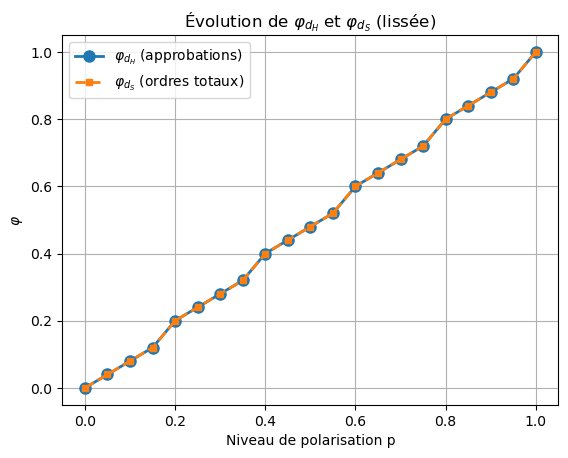

In [11]:
plt.plot(val_p, phi_dh, marker='o', markersize=8, linewidth=2, label=r'$\varphi_{d_H}$ (approbations)')
plt.plot(val_p, phi_ds, marker='s', markersize=5, linestyle='--', linewidth=2, label=r'$\varphi_{d_S}$ (ordres totaux)')
plt.title(r"Évolution de $\varphi_{d_H}$ et $\varphi_{d_S}$ (lissée)")
plt.xlabel("Niveau de polarisation p")
plt.ylabel(r"$\varphi$")
plt.grid(True)
plt.legend()
plt.show()

On observe que les deux courbes sont identiques. Cela s'explique par le fait que nos profils ne contiennent que 2 bulletins distincts (a et ā, ou o et o_oppose). Le k-means sépare donc toujours parfaitement les deux groupes, ce qui donne ũ*₂ = 0. Les facteurs de normalisation (2/(n×m) pour φdH et 4/(n×m²) pour φdS) compensent exactement la différence entre la distance de Hamming et la distance de Spearman, ce qui fait que φdH = φdS = 2×nb_opposé/n pour toute valeur de p.